# 02 – Decision Tree: Basmodell

## Vad är ett beslutsträd?
Tänk dig ett träd med frågor. Varje nod ställer en fråga om datan:
*"Jobbar personen övertid?"*, *"Hur länge har de jobbat här?"* osv.
Svaret skickar oss åt vänster eller höger – tills vi når ett löv som
säger: **"Stannar"** eller **"Slutar"**.

## Varför börjar vi här?
Beslutsträdet är vår **basmodell** – ett enkelt riktmärke att slå.
Om ett mer avancerat ensembletal inte är bättre än detta träd,
har vi gjort något fel.

## Vad ska vi lära oss i denna notebook?
1. Träna ett beslutsträd med `scikit-learn`
2. Utvärdera med rätt mätvärden (F1, ROC-AUC, Recall) – *inte* accuracy
3. Förstå varför ett enda träd ofta **overfittar**
4. Sätta ett riktmärke att slå i kommande notebooks

In [1]:
# ── Imports & konfiguration ────────────────────────────────
import sys
import os

os.chdir("..")  # kör alltid relativt projektroten
sys.path.append(".")

from src.data_processing import load_raw, clean_and_encode, save_clean, split_and_scale
from src.model_training import train_decision_tree
from src.evaluation import evaluate_model, plot_confusion_matrix, plot_roc_curve

DATA_PATH  = "data/attrition_clean.csv"
FIG_PATH   = "outputs/figures"

print("✅ Imports och konfiguration klar!")
print(f"   Datafil  : {DATA_PATH}")
print(f"   Output   : {FIG_PATH}")

✅ Imports och konfiguration klar!
   Datafil  : data/attrition_clean.csv
   Output   : outputs/figures


#### Vad ser vi?
Vi har laddat in alla verktyg vi behöver för denna notebook:

- **data_processing** – laddar och rensar rådata
- **model_training** – tränar beslutsträdet
- **evaluation** – mäter hur bra modellen är och ritar grafer

Sökvägarna är satta så att alla filer hamnar på rätt ställe. ✅

In [2]:
# ── Ladda färdigbearbetad data ─────────────────────────────
import pandas as pd

CLEAN_PATH = "data/attrition_clean.csv"

df_clean = pd.read_csv(CLEAN_PATH)
X_train, X_test, y_train, y_test = split_and_scale(df_clean)

print(f"✅ Laddade rensad data från : {CLEAN_PATH}")
print(f"   Träningsdata : {X_train.shape[0]} rader, {X_train.shape[1]} kolumner")
print(f"   Testdata     : {X_test.shape[0]} rader, {X_test.shape[1]} kolumner")
print(f"   Attrition Yes i träning  : {y_train.sum()} ({y_train.mean():.1%})")
print(f"   Attrition Yes i test     : {y_test.sum()} ({y_test.mean():.1%})")

[data_processing] Split: 1,176 train / 294 test (stratified, test_size=0.2)
✅ Laddade rensad data från : data/attrition_clean.csv
   Träningsdata : 1176 rader, 44 kolumner
   Testdata     : 294 rader, 44 kolumner
   Attrition Yes i träning  : 190 (16.2%)
   Attrition Yes i test     : 47 (16.0%)


## Vad ser vi?

Vi har delat upp datan i två delar:

- **Träningsdata** – 1 176 rader som modellen får lära sig av
- **Testdata** – 294 rader som modellen aldrig sett, används för utvärdering

Viktigt: andelen `Attrition = Yes` är nästan identisk i båda delarna:
- Träning: **16.2 %**
- Test: **16.0 %**

Det betyder att vår **stratifierade split** fungerade – klassobalansen
bevarades. Modellen tränas och testas under samma förutsättningar. ✅

In [3]:
# ── Träna beslutsträdet ────────────────────────────────────
model_dt = train_decision_tree(X_train, y_train)

print(f"   Max djup         : {model_dt.get_depth()}")
print(f"   Antal löv        : {model_dt.get_n_leaves()}")
print(f"   Antal features   : {model_dt.n_features_in_}")

[model_training] Training Decision Tree (baseline)...
[model_training] Decision Tree training complete.
   Max djup         : 15
   Antal löv        : 161
   Antal features   : 44


## Vad ser vi?

Beslutsträdet tränade klart. Tre saker sticker ut:

- **Max djup: 15** – trädet är väldigt djupt. Det betyder att det ställer
  upp till 15 frågor i rad innan det bestämmer sig. Ju djupare, desto mer
  risk för **overfitting** – trädet lär sig rådata utantill istället för
  att generalisera.

- **Antal löv: 161** – trädet har 161 möjliga slutsatser. Det är många!
  Tänk dig ett träd med 161 olika svar – det har troligtvis lärt sig
  brus snarare än mönster.

- **Antal features: 44** – trädet fick tillgång till alla 44 kolumner
  efter one-hot encoding.

> 🚨 Ett opruntat träd med djup 15 och 161 löv är ett klassiskt tecken
> på overfitting. Vi förväntar oss bra resultat på träningsdata men
> sämre på testdata. Det är just detta ensemblemetoder löser!

In [4]:
# ── Utvärdera beslutsträdet ────────────────────────────────
results_dt = evaluate_model(
    model_dt, X_test, y_test, model_name="decision_tree"
)

print(f"\n   F1-score  : {results_dt['f1']}")
print(f"   ROC-AUC   : {results_dt['roc_auc']}")

[evaluation] decision_tree | F1: 0.2609 | ROC-AUC: 0.5609
[evaluation] Results saved to: outputs/results\decision_tree.json

   F1-score  : 0.2609
   ROC-AUC   : 0.5609


## Vad ser vi?

Precis som vi misstänkte – beslutsträdet presterar dåligt på testdata:

- **F1-score: 0.26** – väldigt lågt. Modellen missar majoriteten av de
  anställda som faktiskt slutar. Av alla "Yes"-förutsägelser är många fel,
  och många verkliga "Yes" missas helt.

- **ROC-AUC: 0.56** – nästan som att kasta slant (0.50 = helt slumpmässig
  modell). Modellen är knappt bättre än ren gissning på att *rangordna*
  risk.

### Varför är det så dåligt?
Trädet lärde sig rådata **utantill** under träning (djup 15, 161 löv),
men generaliserar inte till ny data. Det kallas **overfitting**.

| Mått | Värde | Tolkning |
|---|---|---|
| F1-score | 0.26 | Dåligt – missar många som slutar |
| ROC-AUC | 0.56 | Nästan slumpmässigt |

> 💡 Det här är *exakt* varför vi behöver ensemblemetoder.
> Random Forest och XGBoost är byggda för att lösa just detta problem!

[evaluation] Figure saved to: outputs/figures\cm_decision_tree.png


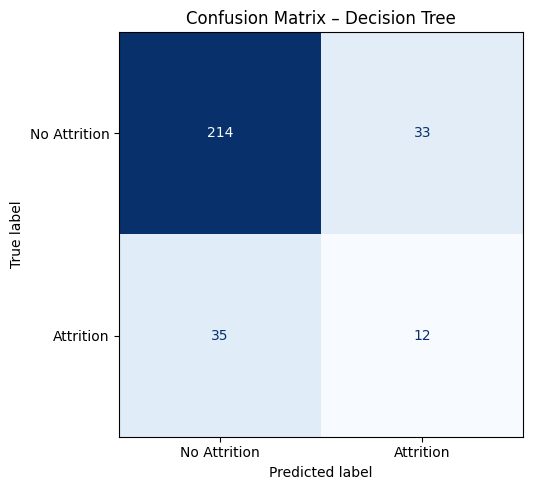

In [5]:
# ── Konfusionsmatris ───────────────────────────────────────
plot_confusion_matrix(
    model_dt, X_test, y_test,
    model_name="decision_tree",
    save=True,
)

## Vad ser vi?

Konfusionsmatrisen visar exakt hur modellens förutsägelser ser ut:

|  | Förutsagt: No | Förutsagt: Yes |
|---|---|---|
| **Verklig: No** | 214 ✅ | 33 ❌ |
| **Verklig: Yes** | 35 ❌ | 12 ✅ |

De fyra rutorna betyder:
- **214** – rätt förutsagt "stannar" (True Negative)
- **12** – rätt förutsagt "slutar" (True Positive)
- **33** – falskt larm, trodde de skulle sluta men stannade (False Positive)
- **35** – missade! Trodde de stannade men slutade (False Negative)

### Det kritiska problemet
Av 47 anställda som faktiskt slutar hittar modellen bara **12 st (26 %)**.
Hela **35 st missas** – de flyger under radarn utan att HR reagerar.

> 🚨 I verkligheten är en missad uppsägning dyr – upp till 150 % av
> årslönen. Att missa 35 av 47 är oacceptabelt för ett HR-verktyg.
> Vi behöver en bättre modell!

[evaluation] Figure saved to: outputs/figures\roc_decision_tree.png


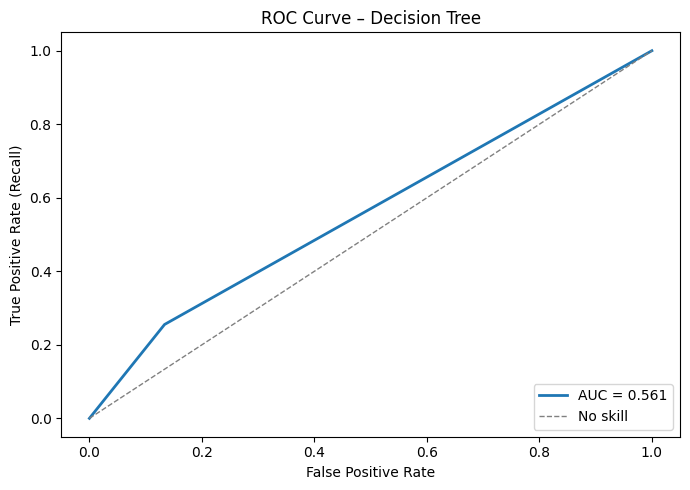

In [6]:
# ── ROC-kurva ──────────────────────────────────────────────
plot_roc_curve(
    model_dt, X_test, y_test,
    model_name="decision_tree",
    save=True,
)

## Vad ser vi?

ROC-kurvan visar hur bra modellen är på att *rangordna* risk över
alla möjliga beslutsgränser.

- **Den blå linjen** – vårt beslutsträd (AUC = 0.561)
- **Den streckade linjen** – en helt slumpmässig modell (AUC = 0.50)

### Tolkning
Kurvan ligger nästan exakt på den streckade linjen. Det betyder att
beslutsträdet knappt är bättre än att slumpmässigt gissa vem som
kommer att sluta.

| AUC-värde | Tolkning |
|---|---|
| 1.00 | Perfekt modell |
| 0.56 | Nästan slumpmässig 🚨 |
| 0.50 | Kastar slant |

### Varför ser kurvan konstig ut?
Den lilla "knycken" tidigt i kurvan (runt FPR = 0.15) är typisk för
ett overfittat träd – det är extremt säkert på några få fall men
misslyckas på resten.

> 💡 **Riktmärket är satt** – AUC 0.56 och F1 0.26 är ribban vi ska
> slå med Random Forest och XGBoost i kommande notebooks!

In [7]:
# ── Sammanfattning ─────────────────────────────────────────
summary = {
    "Modell":     "Decision Tree (baseline)",
    "F1-score":   results_dt["f1"],
    "ROC-AUC":    results_dt["roc_auc"],
    "Rätt Yes":   12,
    "Missade Yes": 35,
}

print("=" * 45)
print("  SAMMANFATTNING – Decision Tree Baseline")
print("=" * 45)
for k, v in summary.items():
    print(f"  {k:<15}: {v}")
print("=" * 45)
print("\n✅ Notebook klar – riktmärket är satt!")
print("   Nästa steg: 03_random_forest.ipynb")

  SAMMANFATTNING – Decision Tree Baseline
  Modell         : Decision Tree (baseline)
  F1-score       : 0.2609
  ROC-AUC        : 0.5609
  Rätt Yes       : 12
  Missade Yes    : 35

✅ Notebook klar – riktmärket är satt!
   Nästa steg: 03_random_forest.ipynb


## Vad ser vi?

Vi har nu ett tydligt riktmärke att slå i kommande notebooks:

| Mått | Decision Tree |
|---|---|
| F1-score | 0.26 |
| ROC-AUC | 0.56 |
| Hittade uppsägningar | 12 av 47 |
| Missade uppsägningar | 35 av 47 |

### Vad lärde vi oss?
1. **Ett enda träd overfittar** – det lär sig rådata utantill men
   generaliserar dåligt till ny data
2. **Accuracy är missvisande** – modellen kan ha hög accuracy men
   ändå missa 35 av 47 uppsägningar
3. **F1 och ROC-AUC är rätt mätvärden** – de avslöjar vad accuracy
   döljer

### Nästa steg
I `03_random_forest.ipynb` introducerar vi **Random Forest** –
ett ensemblemetod som bygger hundratals träd och låter dem rösta
tillsammans. Målet är att slå F1 0.26 och ROC-AUC 0.56 rejält!